# Where the model gets it wrong

The frozen model gets about 61% of validation maps right. Which maps does it miss, and is
there a pattern? Nothing here changes the model.

| Question | Answer |
|---|---|
| Are its mistakes just close games? | No — it gets one-sided maps wrong too (section 6) |
| Does it misjudge particular teams? | No — its worst teams are variance, not bias (section 7) |
| Does it squash strong and weak teams toward 50%? | It looks that way, but luck alone gives the same pattern (section 8) |
| Is it right more often when it's more sure? | No — and a calibrated model would be (section 8) |
| Do any slices stand out? | A few look strong, but about 50 groups were cut; that's luck (sections 2–5) |

**Headline: no pattern in its errors survives a check against luck.** It is close to a
uniform 61% model.

Two claims from the first draft didn't survive: "it predicts mismatches well" (section 4) and
"it squashes teams toward 50%" (section 8). The checks are left in, because they're the
useful part.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from dataset import build_map_table, season_folds, split_season
from features import build_features, feature_columns
from form import load_player_maps, player_form
from model import FINAL_COLUMNS, make_final_model

HALF_LIFE = 5

maps = build_map_table()
learn, test = split_season(maps)
X_agents, y = build_features(learn, feature_columns(maps))
form = player_form(learn, half_life=HALF_LIFE)
X = pd.concat([X_agents[["map_picked_by_a"]], form], axis=1)[FINAL_COLUMNS].astype(float)

# Every validation prediction: each fold's model judging maps it never saw.
chances = []
for learn_rows, check_rows in season_folds(learn):
    model = clone(make_final_model()).fit(X.loc[learn_rows], y.loc[learn_rows])
    chances.append(pd.Series(model.predict_proba(X.loc[check_rows])[:, 1], index=check_rows))
chance_a = pd.concat(chances)

checked = learn.loc[chance_a.index].copy()
checked["chance_a"] = chance_a
checked["right"] = (checked["chance_a"] >= 0.5).astype(int) == checked["team_a_won"]
checked["picker_right"] = (
    checked["map_picked_by"].map({"team_a": 1, "team_b": 0}).fillna(1) == checked["team_a_won"]
)

print(f"{len(checked)} validation maps, {checked['right'].mean():.1%} right overall")

629 validation maps, 61.2% right overall


## 1. How much is just noise?

Small groups bounce around. Every table has a `±` column: how far a group that size can
drift on luck alone. Differences smaller than that aren't findings.

This notebook also cuts the same 629 maps about 50 ways, so one or two groups will stand out
by luck even if nothing is there. The rule the project applied to agents (1 of 27 standing
out is what chance produces) applies here too, especially to results that flatter the model.

In [2]:
def noise(n):
    """How far a group of n maps can drift by chance alone, in percentage points."""
    return 100 * 1.96 * np.sqrt(0.25 / n)


def breakdown(by, label=None):
    """Model accuracy and the picker rule's, side by side, for each group."""
    table = checked.groupby(by, observed=True).agg(
        maps=("right", "size"),
        model=("right", lambda s: round(s.mean() * 100, 1)),
        picker_rule=("picker_right", lambda s: round(s.mean() * 100, 1)),
    )
    table["±"] = table["maps"].map(lambda n: round(noise(n), 1))
    if label:
        table.index.name = label
    return table


for n in (50, 100, 250, 629):
    print(f"  a group of {n:>3} maps can drift ±{noise(n):.1f} points on luck alone")

  a group of  50 maps can drift ±13.9 points on luck alone
  a group of 100 maps can drift ±9.8 points on luck alone
  a group of 250 maps can drift ±6.2 points on luck alone
  a group of 629 maps can drift ±3.9 points on luck alone


## 2. By tournament

In [3]:
breakdown("event").sort_values("model")

,maps,model,picker_rule,±
event,,,,
VCT 2025 Pacific Kickoff,46,50.0,67.4,14.4
VCT 2025 Pacific Stage 1,107,58.9,57.0,9.5
VCT 2025 Americas Stage 1,104,59.6,58.7,9.6
VCT 2025 China Stage 1,105,60.0,48.6,9.6
VCT 2025 EMEA Stage 1,104,60.6,52.9,9.6
Valorant Masters Bangkok 2025,42,61.9,61.9,15.1
VCT 2025 EMEA Kickoff,26,65.4,46.2,19.2
Valorant Masters Toronto 2025,59,71.2,55.9,12.8
VCT 2025 Americas Kickoff,32,71.9,53.1,17.3


The worst is **Pacific Kickoff at 50%**, against the picker rule's 67.4%. Kickoff is the
first event of the year, so nobody has a record yet. Several groups are small enough that the
`±` column matters.

## 3. By how much history the players had

In [4]:
# How many rated maps sat behind the less-known of the two sides, going into each map.
players = load_player_maps(learn).sort_values(["played_at", "match_id"])
seen, history = {}, {}
for (_, match_id), match in players.groupby(["played_at", "match_id"], sort=True):
    for team in (match.iloc[0]["team_a"], match.iloc[0]["team_b"]):
        names = match[match["Team"] == team]["Player"].unique()
        side = np.mean([seen.get(name, 0) for name in names])
        history[match_id] = min(history.get(match_id, np.inf), side)
    for _, performance in match.iterrows():
        if pd.notna(performance["Rating"]):
            seen[performance["Player"]] = seen.get(performance["Player"], 0) + 1

checked["history"] = checked["match_id"].map(history)

# right=False so each band means what its label says: "under 5" is below 5, not 5 or fewer,
# and "20 or more" includes exactly 20. Getting this wrong moved two of these figures by
# three points and invented a ladder that is not there.
checked["history_band"] = pd.cut(checked["history"], [0, 5, 10, 20, 1000], right=False,
                                 labels=["under 5 maps", "5 to 10", "10 to 20", "20 or more"])

breakdown("history_band", "rated maps behind the less-known side")

,maps,model,picker_rule,±
rated maps behind the less-known side,,,,
under 5 maps,131,64.1,57.3,8.6
5 to 10,155,55.5,54.8,7.9
10 to 20,208,60.6,52.9,6.8
20 or more,135,65.9,59.3,8.4


**No ladder:** the thinnest-history group is the second best, and every band sits inside
the others' `±` range.

Notebook 09's steady climb (58.0 / 58.1 / 59.5 / 64.5%) was measured **before** the
combat-score repair, which fixed most of the thin-history maps. Quote that climb only as
describing the earlier model.

## 4. Matches between leagues

The four leagues only meet at Masters and Champions. Each team's home league comes from the
league events it plays in.

In [5]:
league_maps = checked[checked["event"].str.startswith("VCT")]
seen_in = {}
for side in ("team_a", "team_b"):
    for team, event in zip(league_maps[side], league_maps["event"]):
        seen_in.setdefault(team, []).append(event.split()[2])  # "VCT 2025 Americas Stage 1"
home_league = {team: pd.Series(regions).mode()[0] for team, regions in seen_in.items()}

checked["across_regions"] = (
    checked["team_a"].map(home_league) != checked["team_b"].map(home_league)
).map({True: "different leagues", False: "same league"})

breakdown("across_regions", "the two teams are from")

,maps,model,picker_rule,±
the two teams are from,,,,
different leagues,95,69.5,58.9,10.1
same league,534,59.7,55.1,4.2


A 10-point gap. Between-league games come later in the year, when players have more
history, so check it with history held roughly equal:

In [6]:
print("median rated maps of history behind each group:")
print(checked.groupby("across_regions")["history"].median().round(1).to_string())
print()

established = checked[checked["history"] >= 10]
table = established.groupby("across_regions").agg(
    maps=("right", "size"), model=("right", lambda s: round(s.mean() * 100, 1)))
table["±"] = table["maps"].map(lambda n: round(noise(n), 1))
print("among maps where both sides had 10+ rated maps behind them:")
table

median rated maps of history behind each group:
across_regions
different leagues    22.0
same league           9.6

among maps where both sides had 10+ rated maps behind them:


,maps,model,±
across_regions,,,
different leagues,81,72.8,10.9
same league,262,59.5,6.1


**The gap survives:** 72.8% against 59.5%. The first draft explained it as league
strength, meaning mismatches the rating gap can see. The next cell tests that.

In [7]:
# If between-league matches were mismatches, two things should be true:
# the model should have seen a bigger gap between the sides, and the games
# should have been more one-sided. Neither is.
checked["rating_gap"] = form.loc[checked.index, "rating_diff"].abs()
checked["margin"] = (checked["score_a"] - checked["score_b"]).abs()

print(checked.groupby("across_regions").agg(
    maps=("right", "size"),
    model=("right", lambda s: round(s.mean() * 100, 1)),
    gap_the_model_saw=("rating_gap", lambda s: round(s.median(), 3)),
    round_margin=("margin", "median"),
    close_games=("margin", lambda s: f"{(s <= 3).mean() * 100:.0f}%"),
).to_string())

# And the direct question, across every map: does a bigger gap mean a better call?
gap_band = pd.qcut(checked["rating_gap"], 5, labels=["smallest", "2", "3", "4", "biggest"])
print("\naccuracy by how far apart the model thought the two sides were:")
print(checked.groupby(gap_band, observed=True).agg(
    maps=("right", "size"),
    median_gap=("rating_gap", lambda s: round(s.median(), 3)),
    model=("right", lambda s: round(s.mean() * 100, 1)),
).to_string())

link = checked["rating_gap"].corr(checked["right"].astype(float))
print(f"\ncorrelation between the size of the gap and getting the map right: {link:+.3f}")

                   maps  model  gap_the_model_saw  round_margin close_games
across_regions                                                             
different leagues    95   69.5              0.047           4.0         41%
same league         534   59.7              0.065           5.0         35%

accuracy by how far apart the model thought the two sides were:
            maps  median_gap  model
rating_gap                         
smallest     118       0.010   63.6
2            113       0.037   57.5
3            115       0.061   60.0
4            116       0.099   65.5
biggest      115       0.161   60.9

correlation between the size of the gap and getting the map right: -0.001


**The mismatch story fails:**

- The model saw a **smaller** gap in between-league games (0.047 against 0.065).
- Those games were **closer**: a 4-round median margin against 5.
- Across all 629 maps, the size of the gap has no link to being right (correlation −0.001).

That leaves a 10-point difference on 95 maps, with a ±10 range, picked out of about 50
groups. **Chance is the most likely explanation.** The 69.5% is a real measurement; the
story behind it wasn't.

## 5. Who chose the map

In [8]:
table = breakdown("map_picked_by", "the map was chosen by")
table["median history"] = checked.groupby("map_picked_by")["history"].median().round(1)
table

,maps,model,picker_rule,±,median history
the map was chosen by,,,,,
decider,103,68.9,60.2,9.7,10.0
team_a,264,56.4,53.4,6.0,11.0
team_b,262,63.0,56.1,6.1,11.0


**It does best on deciders** (68.9%, ±9.7), and not because of history. One reading: a
team picks its best map, which partly cancels a strength gap, while the decider is neutral
ground. On 103 maps, treat that as a guess.

"Team A chose" (56.4%) against "team B chose" (63.0%) is noise: which team is called A is
arbitrary. The raw data has a similar gap (the picker won 53.0% of maps team A chose and
56.7% of those team B chose).

## 6. Are the mistakes just close games?

In [9]:
checked["margin"] = (checked["score_a"] - checked["score_b"]).abs()

summary = checked.groupby("right").agg(
    maps=("margin", "size"),
    median_margin=("margin", "median"),
    close_games=("margin", lambda s: round((s <= 3).mean() * 100, 1)),
    thumpings=("margin", lambda s: round((s >= 8).mean() * 100, 1)),
)
summary.index = ["got it wrong", "got it right"]
summary

,maps,median_margin,close_games,thumpings
got it wrong,244,5.0,37.3,23.0
got it right,385,5.0,35.3,25.5


**No.** Maps it gets wrong have the same median margin as maps it gets right, and about the
same share of close and one-sided games. "It only loses the toss-ups" would be flattering,
and it isn't true.

## 7. Is it misjudging particular teams?

A team it consistently over- or under-rates would be a fixable bias.

In [10]:
rows = []
for team in sorted(set(checked["team_a"]) | set(checked["team_b"])):
    as_a, as_b = checked["team_a"] == team, checked["team_b"] == team
    maps_played = int(as_a.sum() + as_b.sum())
    if maps_played < 20:
        continue
    expected = pd.concat([checked.loc[as_a, "chance_a"], 1 - checked.loc[as_b, "chance_a"]])
    actual = pd.concat([checked.loc[as_a, "team_a_won"], 1 - checked.loc[as_b, "team_a_won"]])
    right = int(checked.loc[as_a, "right"].sum() + checked.loc[as_b, "right"].sum())
    rows.append({
        "team": team,
        "maps": maps_played,
        "model right %": round(100 * right / maps_played, 1),
        "model expected them to win %": round(expected.mean() * 100, 1),
        "they actually won %": round(actual.mean() * 100, 1),
    })

teams = pd.DataFrame(rows).set_index("team")
teams["over/under-rated by"] = (teams["model expected them to win %"]
                                - teams["they actually won %"]).round(1)
teams.sort_values("model right %").head(6)

,maps,model right %,model expected them to win %,they actually won %,over/under-rated by
team,,,,,
TALON,31,38.7,49.0,45.2,3.8
Nongshim RedForce,25,40.0,51.2,52.0,-0.8
Team Vitality,32,53.1,51.8,53.1,-1.3
Evil Geniuses,20,55.0,48.3,55.0,-6.7
Natus Vincere,20,55.0,48.5,45.0,3.5
Bilibili Gaming,36,55.6,55.0,55.6,-0.6


The teams it reads worst **aren't misjudged**: it expected TALON to win 49% and they won
45%, Nongshim RedForce 51% against 52%. It knows how good they are but can't call their maps.
That's variance.

The teams it reads best:

In [11]:
teams.sort_values("model right %").tail(5)

,maps,model right %,model expected them to win %,they actually won %,over/under-rated by
team,,,,,
DRX,39,69.2,51.2,61.5,-10.3
Paper Rex,47,70.2,54.6,63.8,-9.2
Sentinels,54,72.2,49.5,55.6,-6.1
Team Liquid,56,73.2,52.1,55.4,-3.3
BBL Esports,27,74.1,50.2,55.6,-5.4


These all look **under-rated**: DRX expected 51%, actual 62%; Paper Rex 55% against 64%.
Is that true across every team with 20+ maps?

In [12]:
# A calibrated model would have these two columns matching, giving a slope of 1.
# Above 1 means the model does not commit far enough in either direction.
slope, _ = np.polyfit(teams["model expected them to win %"], teams["they actually won %"], 1)

print(f"teams measured: {len(teams)}")
print(f"slope of what happened against what was expected: {slope:.2f}   (1.00 = calibrated)")
print(f"the model's opinion of a team spans "
      f"{teams['model expected them to win %'].max() - teams['model expected them to win %'].min():.0f}"
      f" points; reality spans "
      f"{teams['they actually won %'].max() - teams['they actually won %'].min():.0f}")

strong = teams[teams["they actually won %"] >= 55]
weak = teams[teams["they actually won %"] <= 45]
print(f"\nteams that won 55%+ of their maps: under-rated by "
      f"{-strong['over/under-rated by'].mean():.1f} points on average ({len(strong)} teams)")
print(f"teams that won 45%- of their maps: over-rated by "
      f"{weak['over/under-rated by'].mean():.1f} points on average ({len(weak)} teams)")

teams measured: 26
slope of what happened against what was expected: 1.52   (1.00 = calibrated)
the model's opinion of a team spans 9 points; reality spans 27

teams that won 55%+ of their maps: under-rated by 7.8 points on average (12 teams)
teams that won 45%- of their maps: over-rated by 7.7 points on average (3 teams)


At face value, yes: the slope is 1.52 (1.00 would be calibrated), the model's view of teams
spans 9 points against 27 in reality, and strong teams look under-rated by about 8 points.
The first draft called this "the one real finding". The next section checks it against luck.

## 8. Is that more than luck?

Simulate 5,000 seasons in which the model is **perfectly calibrated**: each map's winner is
drawn from the model's own probability. Recompute the same three team numbers, plus the
map-level question of whether it's right more often when it's more sure.

In [13]:
# Seasons where the model is perfectly calibrated: each map's winner drawn from its own
# probability. Numbers are rounded as in the team table above, so the actual values match.
p = checked["chance_a"].to_numpy()
as_a = np.array([(checked["team_a"] == t).to_numpy() for t in teams.index], dtype=float)
as_b = np.array([(checked["team_b"] == t).to_numpy() for t in teams.index], dtype=float)
maps_each = as_a.sum(1) + as_b.sum(1)
expected = np.round((as_a @ p + as_b @ (1 - p)) / maps_each * 100, 1)


def team_numbers(team_a_won):
    actual = np.round((as_a @ team_a_won + as_b @ (1 - team_a_won)) / maps_each * 100, 1)
    strong = actual >= 55
    return (np.polyfit(expected, actual, 1)[0],          # slope
            actual.max() - actual.min(),                   # spread of results, points
            (actual - expected)[strong].mean())            # how under-rated winners look


actual = team_numbers(checked["team_a_won"].to_numpy().astype(float))
rng = np.random.default_rng(0)
luck = np.array([team_numbers((rng.random(len(p)) < p).astype(float)) for _ in range(5000)])

names = ["slope", "spread of team results (points)", "teams winning 55%+ under-rated by"]
for i, name in enumerate(names):
    print(f"{name:34} actual {actual[i]:5.2f}   luck alone: median {np.median(luck[:, i]):5.2f}, "
          f"at least this big in {(luck[:, i] >= actual[i]).mean():.0%} of seasons")

# Per map: is it right more often when it is more sure? A calibrated model would be.
sure = np.abs(p - 0.5)
link = np.corrcoef(sure, checked["right"].to_numpy().astype(float))[0, 1]
luck_link = np.array([np.corrcoef(sure, ((p >= 0.5) == (rng.random(len(p)) < p)).astype(float))[0, 1]
                      for _ in range(2000)])
print(f"\nhow sure it is vs being right, per map: actual {link:+.3f}; "
      f"calibrated model: median {np.median(luck_link):+.3f}, "
      f"this low in {(luck_link <= link).mean():.1%} of seasons")

slope                              actual  1.52   luck alone: median  0.97, at least this big in 22% of seasons
spread of team results (points)    actual 27.20   luck alone: median 36.50, at least this big in 93% of seasons
teams winning 55%+ under-rated by  actual  7.78   luck alone: median  8.90, at least this big in 75% of seasons

how sure it is vs being right, per map: actual +0.007; calibrated model: median +0.105, this low in 0.6% of seasons


**The team pattern is luck.** A perfectly calibrated model shows it just as often:

| | Actual | Luck alone (median) | Seasons at least this big |
|---|---|---|---|
| Slope | 1.52 | 0.97 | 22% |
| Spread of team results | 27 points | 36 points | 93% |
| Teams winning 55%+ look under-rated by | 7.8 points | 8.9 points | 75% |

With only a few dozen maps per team, results swing a lot. Teams picked for winning 55%+ were
partly lucky, so any model looks like it under-rated them (regression to the mean). And a
27-point spread is narrower than luck usually gives.

**What isn't luck is the map-level result.** A calibrated model is right noticeably more often
when it's more sure (correlation about +0.10). This one isn't (+0.007), which happens in 0.6%
of lucky seasons. Notebook 09 saw the same thing with confidence bands.

## 9. The picture in one chart

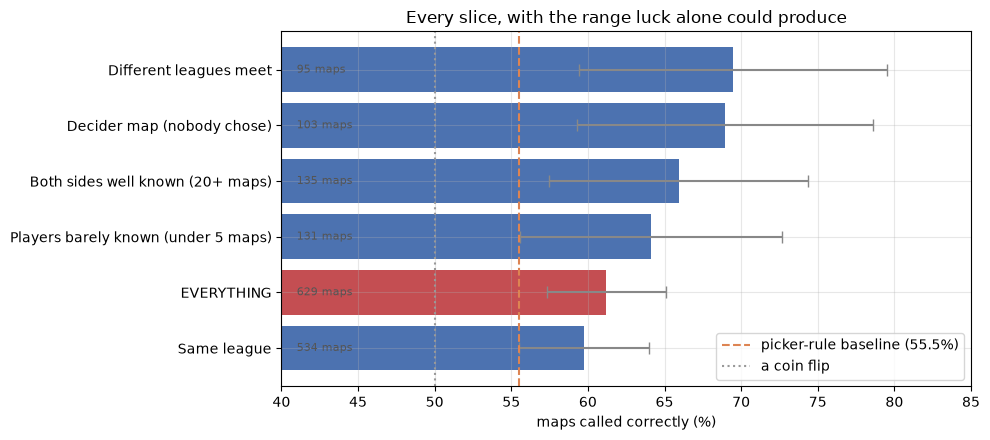

In [14]:
slices = {
    "Different leagues meet": checked["across_regions"] == "different leagues",
    "Decider map (nobody chose)": checked["map_picked_by"] == "decider",
    "Both sides well known (20+ maps)": checked["history"] >= 20,
    "EVERYTHING": pd.Series(True, index=checked.index),
    "Same league": checked["across_regions"] == "same league",
    "Players barely known (under 5 maps)": checked["history"] < 5,
}

rows = [(name, checked.loc[mask, "right"].mean() * 100, int(mask.sum())) for name, mask in slices.items()]
chart = pd.DataFrame(rows, columns=["slice", "accuracy", "maps"]).sort_values("accuracy")

fig, ax = plt.subplots(figsize=(10, 4.5))
colours = ["#c44e52" if name == "EVERYTHING" else "#4c72b0" for name in chart["slice"]]
ax.barh(chart["slice"], chart["accuracy"], xerr=chart["maps"].map(noise),
        color=colours, ecolor="#888888", capsize=4)
ax.axvline(55.5, color="#dd8452", linestyle="--", label="picker-rule baseline (55.5%)")
ax.axvline(50, color="#999999", linestyle=":", label="a coin flip")
ax.set_xlim(40, 85)
ax.set_xlabel("maps called correctly (%)")
ax.set_title("Every slice, with the range luck alone could produce")
for y, (accuracy, n) in enumerate(zip(chart["accuracy"], chart["maps"])):
    ax.text(41, y, f"{n} maps", va="center", fontsize=8, color="#555555")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. What this means

**No pattern in the errors survives a check against luck.** The model is a roughly uniform
61% model: it has found the one signal there is (which side has been playing better), and it
doesn't know when it's right.

| Story tested | Verdict |
|---|---|
| It only loses close games | No (section 6) |
| It misjudges particular teams | No (section 7) |
| It does well on mismatches | No, luck (section 4) |
| It squashes teams toward 50% | No, luck (section 8) |
| It's right more often when more sure | No, and this one isn't luck (section 8) |

**What would help:** something that separates evenly matched teams, which is nearly every map.
Not more columns or another kind of model; notebooks 08 and 09 closed both. And not chasing
the slices or the worst teams above: none survived a control.